In [1]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import scanpy as sc

cell_types = ["hepg2", "jurkat", "rpe1", "K562"]
grand_dict = {}

main_chroms = {f"chr{i}" for i in range(1, 23)} | {"chrX", "chrY"}

for ct in cell_types:
    adata = sc.read_h5ad(f"/cwork/hl489/Pertb_benchmark/DataSet2/{ct}/hvg5000/filter_hvgall_logNor.h5ad", backed="r")
    var_filtered = adata.var[adata.var['chr'].isin(main_chroms)]
    grand_dict.update(dict(var_filtered['gene_name']))



In [8]:
from results_analysis_helper import *

folder = Path("/cwork/hl489/Pertb_benchmark/DataSet2")
keywords = ["K562", "HEK293T", "HCT116"]

dfs = []
for f in sorted(folder.glob("*_hvg5000.tsv")):
    if any(k in f.name for k in keywords):
        df = pd.read_csv(f, sep="\t")
        df["source_file"] = f.name
        dfs.append(df)

df1 = pd.concat(dfs, ignore_index=True)
df1.drop(columns=["source_file"], inplace=True)

df = pd.read_csv("/cwork/hl489/Pertb_benchmark/DataSet2/performance_jurkat_rpe1_hepg2_hvg5000.tsv", sep='\t')
# df = df[df.metric != "wasserstein"]
# df.drop(columns=["split"], inplace=True)
df.columns
df.metric.unique()

df = pd.concat([df, df1], ignore_index=True)

cell_types = "all"
# cell_types = ["HCT116", "HEK293T"] # "K562", "HCT116", "HEK293T", "hepg2", "jurkat", "rpe1"
if cell_types != "all":
    df = df[df.DataSet.isin(cell_types)]

cell_types_joined = "_".join(cell_types) if isinstance(cell_types, list) else cell_types
# Additional Filters



df = df[(df.DEG >= 5000) & (df.method != "controlMean")]

# Rename existing metrics for consistency
df['metric'] = df['metric'].replace({
    'pearson_distance': 'pearson_distance_delta',
    'spearman_distance': 'spearman_distance_raw',
})

# make sure we only look at pearson and spearman
df = df[df.metric.isin(['pearson_distance_delta', 'spearman_distance_raw'])]
# Load gene_perf from both parquet groups and concat
# _geneperf_groups = ["K562_HCT116_HEK293T", "hepg2_jurkat_rpe1"]
# gene_perf = pd.concat([
#     pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_{g}_hvg5000_alldeg_detail.parquet")
#     for g in _geneperf_groups
# ], ignore_index=True)
# # if cell_types != "all":
# #     gene_perf = gene_perf[gene_perf['dataset'].isin(cell_types)]

# new_metrics = compute_new_corr_metrics(
#     gene_perf, deg=10000
# )

Computed from gene_perf (DEG=10000):
  pearson_distance_raw:    3621 entries  (skipped 0 due to zero std)
  spearman_distance_raw:   3621 entries  (skipped 0 due to zero std)
  pearson_distance_delta:  3621 entries  (skipped 0 due to zero std)
  spearman_distance_delta: 3621 entries  (skipped 0 due to zero std)
  mean_absolute_error_delta: 3621 entries


In [34]:
_geneperf_groups = ["K562_HCT116_HEK293T", "hepg2_jurkat_rpe1"]
gene_perf = pd.concat([
    pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_{g}_hvg5000_detail.parquet")
    for g in _geneperf_groups
], ignore_index=True)

# filter for methods

gene_perf1 = gene_perf[gene_perf.method == "trainMean"]
# if cell_types != "all":
#     gene_perf = gene_perf[gene_perf['dataset'].isin(cell_types)]

In [35]:
gene_perf.columns

Index(['dataset', 'method', 'split', 'perturbation', 'gene', 'mean_pred',
       'mean_true', 'mean_pred_delta', 'mean_true_delta', 'var_pred',
       'var_true', 'abs_error', 'squared_error', 'abs_error_delta',
       'squared_error_delta', 'deg_rank', 'n_stim_cells', 'n_imp_cells'],
      dtype='object')

In [42]:
new_metrics = compute_new_corr_metrics(
    gene_perf1, deg=1000
)

Computed from gene_perf (DEG=1000):
  pearson_distance_raw:    3612 entries  (skipped 9 due to zero std)
  spearman_distance_raw:   3612 entries  (skipped 9 due to zero std)
  pearson_distance_delta:  3621 entries  (skipped 0 due to zero std)
  spearman_distance_delta: 3621 entries  (skipped 0 due to zero std)
  mean_absolute_error_delta: 3621 entries


In [38]:
new_metrics.DEG.unique()

array([10000])

In [45]:
pivot = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=1000, top_n=30, agg_func='mean')

Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=1000
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Lower = better | n=284 common perturbations

TOP 30 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
ERCC2    0.5862   0.4126  0.2280  0.4485  0.2537  0.1553     0.3474
POLR2H   0.3136   0.4658  0.4023  0.2021  0.5741  0.1945     0.3587
CSE1L    0.5757   0.5309  0.3517  0.2665  0.3486  0.1022     0.3626
MCM3     0.5496   0.5285  0.3785  0.1948  0.4822  0.0567     0.3651
ELL      0.7120   0.6568  0.3984  0.2031  0.1928  0.0363     0.3666
GTF2E2   0.8759   0.5385  0.2618  0.2235  0.1742  0.1313     0.3675
PAF1     0.6220   0.5135  0.4393  0.1521  0.3047  0.1840     0.3693
SSRP1    0.6272   0.3769  0.2435  0.2799  0.5464  0.2189     0.38

In [4]:
# pivot = perturbation_analysis(df, method="trainMean", metric="pearson_distance_raw", deg=5000, top_n=20, agg_func='mean')
pivot = perturbation_analysis(df, method="trainMean", metric="spearman_distance_delta", deg=5000, top_n=20, agg_func='mean')

TypeError: unbound method set.intersection() needs an argument

In [5]:
# import pandas as pd

# dfs = []
# for i in ["K562", "HCT116", "HEK293T"]:
#     p = f"/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_{i}_trainMean_full_hvg5000_detail.parquet"
#     dfs.append(pd.read_parquet(p))

# gene_perf = pd.concat(dfs, ignore_index=True)

import pandas as pd

gene_perf = pd.concat(
    [
        pd.read_parquet(
            f"/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_{ds}_hvg5000_trainMeanfull_s5to9_allgenes_detail.parquet"
        ).assign(dataset=ds)
        for ds in ["HEK293T", "HCT116"]
    ],
    ignore_index=True,
)

print(gene_perf.shape)



# geneperf_HEK293T_hvg5000_trainMeanfull_s5to9_deg10000_detail.parquet
# geneperf_HCT116_hvg5000_trainMeanfull_s5to9_deg10000_detail.parquet


(28892841, 18)


In [6]:
gene_perf["gene"] = gene_perf["gene"].map(
    lambda g: grand_dict.get(g, None) if g.startswith("ENSG") else g
)

# gene_perf.dropna(subset=["gene"], inplace=True)

display(gene_perf.head())
display(gene_perf[gene_perf.isna().any(axis=1)])

,dataset,method,split,perturbation,gene,mean_pred,mean_true,mean_pred_delta,mean_true_delta,var_pred,var_true,abs_error,squared_error,abs_error_delta,squared_error_delta,deg_rank,n_stim_cells,n_imp_cells
0,HEK293T,trainMean_full_noMatch,5,SRPK1,A1BG,0.281497,0.291457,0.023275,0.033235,0.0,0.106107,0.009960,0.000099,0.009960,0.000099,1,167,167
1,HEK293T,trainMean_full_noMatch,5,SRPK1,AACS,0.143505,0.121172,0.012746,-0.009586,0.0,0.060253,0.022333,0.000499,0.022333,0.000499,2,167,167
2,HEK293T,trainMean_full_noMatch,5,SRPK1,AAK1,0.489971,0.443624,0.043859,-0.002487,0.0,0.169401,0.046346,0.002148,0.046346,0.002148,3,167,167
3,HEK293T,trainMean_full_noMatch,5,SRPK1,AATF,0.756058,0.715904,0.062950,0.022797,0.0,0.206171,0.040154,0.001612,0.040154,0.001612,4,167,167
4,HEK293T,trainMean_full_noMatch,5,SRPK1,ABCA1,0.035847,0.020698,0.004448,-0.010702,0.0,0.010908,0.015149,0.000229,0.015149,0.000229,5,167,167


,dataset,method,split,perturbation,gene,mean_pred,mean_true,mean_pred_delta,mean_true_delta,var_pred,var_true,abs_error,squared_error,abs_error_delta,squared_error_delta,deg_rank,n_stim_cells,n_imp_cells


In [7]:
new_metrics = compute_new_corr_metrics(
    gene_perf, deg=10000
)

Computed from gene_perf (DEG=10000):
  pearson_distance_raw:    5400 entries  (skipped 0 due to zero std)
  spearman_distance_raw:   5400 entries  (skipped 0 due to zero std)
  pearson_distance_delta:  5400 entries  (skipped 0 due to zero std)
  spearman_distance_delta: 5400 entries  (skipped 0 due to zero std)
  mean_absolute_error_delta: 5400 entries


In [8]:
new_metrics.method.value_counts()

method
trainMean_full_K562Match               9000
trainMean_full_K562matchfilterfirst    9000
trainMean_full_noMatch                 9000
Name: count, dtype: int64

In [9]:
pivot = perturbation_analysis(new_metrics, method="trainMean_full_K562matchfilterfirst", metric="spearman_distance_delta", deg=10000, top_n=50, agg_func='mean')

Cell lines: ['HCT116', 'HEK293T']
Common perturbations: 899
Method=trainMean_full_K562matchfilterfirst, Metric=spearman_distance_delta, DEG=10000
Cell lines: ['HCT116', 'HEK293T']
Lower = better | n=899 common perturbations

TOP 50 BEST PREDICTED (lowest spearman_distance_delta)
DataSet   HCT116  HEK293T  mean_perf
perturb                             
POLR2H    0.3619   0.3859     0.3739
RUVBL2    0.4911   0.4009     0.4460
POLR2A    0.4809   0.4373     0.4591
PAF1      0.5909   0.4210     0.5060
ZNF567    0.5997   0.4214     0.5106
RPA1      0.5417   0.5001     0.5209
ETV5      0.5811   0.4696     0.5254
CDK7      0.5392   0.5184     0.5288
E4F1      0.4351   0.6264     0.5307
SSRP1     0.6438   0.4278     0.5358
SUPT5H    0.5747   0.5276     0.5512
FIP1L1    0.3955   0.7068     0.5512
SFPQ      0.5620   0.5533     0.5576
CASP8AP2  0.6179   0.5114     0.5646
RBM25     0.5708   0.5612     0.5660
DMAP1     0.6971   0.4375     0.5673
CDC73     0.5770   0.5605     0.5688
POLR2B    0.7054 

In [10]:
pivot

DataSet,HCT116,HEK293T,mean_perf,median_perf,std_perf,range_perf,rank_HCT116,rank_HEK293T,max_rank_diff,delta_HCT116,delta_HEK293T,max_outlier_cellline,max_outlier_value
perturb,,,,,,,,,,,,,
AATF,0.8976,0.9168,0.90720,0.90720,0.013576,0.0192,314.0,403.0,89.0,-0.0192,0.0192,HCT116,0.0192
ADNP,0.8289,0.9009,0.86490,0.86490,0.050912,0.0720,187.0,382.0,195.0,-0.0720,0.0720,HCT116,0.0720
ADNP2,0.6814,0.6864,0.68390,0.68390,0.003536,0.0050,56.0,127.0,71.0,-0.0050,0.0050,HCT116,0.0050
AEBP2,0.9437,0.6438,0.79375,0.79375,0.212061,0.2999,437.5,101.0,336.5,0.2999,-0.2999,HCT116,0.2999
AFF1,0.9535,0.8775,0.91550,0.91550,0.053740,0.0760,464.0,352.0,112.0,0.0760,-0.0760,HCT116,0.0760
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF84,0.7989,0.9479,0.87340,0.87340,0.105359,0.1490,146.0,438.0,292.0,-0.1490,0.1490,HCT116,0.1490
ZNF891,1.1572,0.9851,1.07115,1.07115,0.121693,0.1721,855.0,487.0,368.0,0.1721,-0.1721,HCT116,0.1721
ZNF92,1.1709,1.0992,1.13505,1.13505,0.050700,0.0717,871.0,626.5,244.5,0.0717,-0.0717,HCT116,0.0717


In [11]:
# datasets = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
datasets = ['HCT116', 'HEK293T']
# datasets = ['K562']
long = pivot[datasets].stack().reset_index()
long.columns = ['perturbation', 'cell_type', 'performance']
long.to_parquet("residual_datasets/HCTHEK_perf.parquet", index=False)

# STOP HERE

In [47]:
df1[df1.method == "trainMean"].metric.value_counts()

metric
pearson_distance_delta    1800
spearman_distance_raw     1800
Name: count, dtype: int64

In [31]:
df1.method.value_counts()

method
trainMean_full_noMatch                 5400
trainMean_full_K562matchfilterfirst    5400
trainMean_full_K562Match               5400
GEARS                                  3600
scGPT                                  3600
trainMean                              3600
CPA                                    3600
Name: count, dtype: int64

In [58]:
pivot = perturbation_analysis(df1, method="trainMean_full_K562matchfilterfirst", metric="spearman_distance_delta", deg=10000, top_n=20, agg_func='mean')

Cell lines: ['HCT116', 'HEK293T']
Common perturbations: 899
Method=trainMean_full_K562matchfilterfirst, Metric=spearman_distance_delta, DEG=10000
Cell lines: ['HCT116', 'HEK293T']
Lower = better | n=899 common perturbations

TOP 20 BEST PREDICTED (lowest spearman_distance_delta)
DataSet   HCT116  HEK293T  mean_perf
perturb                             
POLR2H    0.3619   0.3859     0.3739
RUVBL2    0.4911   0.4009     0.4460
POLR2A    0.4809   0.4373     0.4591
PAF1      0.5909   0.4210     0.5060
ZNF567    0.5997   0.4214     0.5106
RPA1      0.5417   0.5001     0.5209
ETV5      0.5811   0.4696     0.5254
CDK7      0.5392   0.5184     0.5288
E4F1      0.4351   0.6264     0.5307
SSRP1     0.6438   0.4278     0.5358
SUPT5H    0.5747   0.5276     0.5512
FIP1L1    0.3955   0.7068     0.5512
SFPQ      0.5620   0.5533     0.5576
CASP8AP2  0.6179   0.5114     0.5646
RBM25     0.5708   0.5612     0.5660
DMAP1     0.6971   0.4375     0.5673
CDC73     0.5770   0.5605     0.5688
POLR2B    0.7054 

In [44]:
sub = df1[(df1['method'] == "trainMean") &
          (df1['metric'] == "pearson_distance_raw")]
print(len(sub), sub['DataSet'].unique() if len(sub) else "no rows")


0 no rows


In [24]:
# datasets = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
datasets = ['HCT116', 'HEK293T']
# datasets = ['K562']
long = pivot[datasets].stack().reset_index()
long.columns = ['perturbation', 'cell_type', 'performance']
long.to_parquet("residual_datasets/HCTHEK_perf.parquet", index=False)


In [18]:
long.shape[0]/2

899.0

In [12]:
from results_modeling_helper import method_complementarity

pivot_all = method_complementarity(
    df, 
    metric="spearman_distance_delta", 
    deg=10000, 
    baseline="trainMean"
)


Method complementarity (spearman_distance_delta, DEG=10000, agg=median)
  284 shared perturbations across 6 cell types

Pairwise Spearman correlation of per-perturbation performance:

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean: 1704  (100.0%)

Median spearman_distance_delta (lower is better):
        trainMean: 0.7987
      oracle_best: 0.7987

Wilcoxon signed-rank test (oracle_best vs each method):


ValueError: zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements.

Oracle gain over trainMean:
  Mean:   0.0417
  Median: 0.0000
  Max:    0.7355
  Cases with gain > 0: 468/1704 (27.5%)
  Cases with gain > 0.1: 234/1704 (13.7%)
  Cases with gain > 0.3: 76/1704 (4.5%)


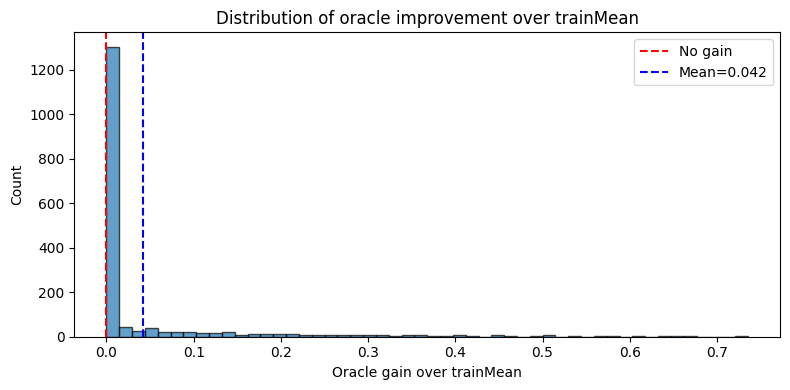

In [33]:
# How much does the oracle beat trainMean?
pivot_all['oracle_gain'] = pivot_all['trainMean'] - pivot_all['oracle_best']

print(f"Oracle gain over trainMean:")
print(f"  Mean:   {pivot_all['oracle_gain'].mean():.4f}")
print(f"  Median: {pivot_all['oracle_gain'].median():.4f}")
print(f"  Max:    {pivot_all['oracle_gain'].max():.4f}")
print(f"  Cases with gain > 0: {(pivot_all['oracle_gain'] > 0).sum()}/{len(pivot_all)} "
      f"({(pivot_all['oracle_gain'] > 0).mean():.1%})")
print(f"  Cases with gain > 0.1: {(pivot_all['oracle_gain'] > 0.1).sum()}/{len(pivot_all)} "
      f"({(pivot_all['oracle_gain'] > 0.1).mean():.1%})")
print(f"  Cases with gain > 0.3: {(pivot_all['oracle_gain'] > 0.3).sum()}/{len(pivot_all)} "
      f"({(pivot_all['oracle_gain'] > 0.3).mean():.1%})")

# Distribution of gains
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pivot_all['oracle_gain'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='No gain')
ax.axvline(pivot_all['oracle_gain'].mean(), color='blue', linestyle='--', label=f"Mean={pivot_all['oracle_gain'].mean():.3f}")
ax.set_xlabel('Oracle gain over trainMean')
ax.set_ylabel('Count')
ax.set_title('Distribution of oracle improvement over trainMean')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Which perturbations does the oracle NOT pick trainMean for?
non_tm = pivot_all[pivot_all['best_method'] != 'trainMean'].copy()
non_tm['improvement'] = non_tm['trainMean'] - non_tm['oracle_best']
non_tm = non_tm.sort_values('improvement', ascending=False)

print(f"Oracle picks non-trainMean for {len(non_tm)}/{len(pivot_all)} cases\n")

# Break down by which method wins
for method in non_tm['best_method'].unique():
    sub = non_tm[non_tm['best_method'] == method]
    print(f"\n{'='*60}")
    print(f"{method} wins over trainMean: {len(sub)} cases")
    print(f"Median improvement: {sub['improvement'].median():.4f}")
    print(f"{'='*60}")
    display(sub[['trainMean', method, 'oracle_best', 'improvement']].head(20))

# Per-perturbation summary: which method wins most across cell types?
best_by_pert = pivot_all.groupby('perturb')['best_method'].value_counts().unstack(fill_value=0)
best_by_pert['consensus'] = best_by_pert.max(axis=1)
best_by_pert['dominant'] = best_by_pert.drop(columns='consensus').idxmax(axis=1)

# Perturbations where a non-trainMean method consistently wins
non_tm_dominant = best_by_pert[best_by_pert['dominant'] != 'trainMean'].sort_values('consensus', ascending=False)
print(f"\nPerturbations where non-trainMean consistently wins: {len(non_tm_dominant)}")
display(non_tm_dominant.head(60))

# Perturbations where trainMean dominates across cell types
tm_dominant = best_by_pert[best_by_pert['dominant'] == 'trainMean'].sort_values('consensus', ascending=False)
print(f"Perturbations where trainMean consistently wins: {len(tm_dominant)}")
display(tm_dominant.head(60))




Oracle picks non-trainMean for 468/1704 cases


scGPT wins over trainMean: 203 cases
Median improvement: 0.1154


method           trainMean   scGPT  oracle_best  improvement
DataSet perturb                                             
HEK293T PSMD1       1.1738  0.4383       0.4383       0.7355
        CDK2        1.2245  0.4995       0.4995       0.7250
        NCOA4       1.1175  0.4492       0.4492       0.6683
        SMC3        1.1333  0.4719       0.4719       0.6614
        NELFA       1.1648  0.5877       0.5877       0.5771
        MLLT6       1.0590  0.5178       0.5178       0.5412
        GPS2        1.1584  0.6243       0.6243       0.5341
        ALYREF      1.1817  0.6494       0.6494       0.5323
HCT116  MYC         1.1840  0.6722       0.6722       0.5118
        CDK2        1.0715  0.5616       0.5616       0.5099
        KDM1A       1.2574  0.7535       0.7535       0.5039
HEK293T ZBTB44      1.1762  0.6752       0.6752       0.5010
HCT116  TOP2A       1.2011  0.7029       0.7029       0.4982
        ALYREF      1.1001  0.6056       0.6056       0.4945
        DONSON      0.9867  0.5162       0.5162       0.4705
        RUVBL1      1.0342  0.5761       0.5761       0.4581
HEK293T METTL14     0.9902  0.5348       0.5348       0.4554
        HDAC3       1.1132  0.6589       0.6589       0.4543
HCT116  ZNF830      1.1522  0.7011       0.7011       0.4511
HEK293T NPM1        0.9551  0.5105       0.5105       0.4446


GEARS wins over trainMean: 76 cases
Median improvement: 0.0852


method           trainMean   GEARS  oracle_best  improvement
DataSet perturb                                             
HEK293T NCAPH2      1.2260  0.5511       0.5511       0.6749
HCT116  PHF5A       1.2324  0.5894       0.5894       0.6430
HEK293T YBX1        1.1967  0.5875       0.5875       0.6092
        TTF2        1.0917  0.5283       0.5283       0.5634
        SOD1        1.0639  0.5541       0.5541       0.5098
        MYBL2       1.1167  0.6148       0.6148       0.5019
HCT116  GTF3C5      1.2696  0.7800       0.7800       0.4896
HEK293T PCBP2       1.0818  0.6645       0.6645       0.4173
        HJURP       1.0693  0.6588       0.6588       0.4105
        KDM5C       1.1379  0.7323       0.7323       0.4056
        TCOF1       1.0848  0.6913       0.6913       0.3935
HCT116  NCOA4       1.2388  0.8832       0.8832       0.3556
        PCF11       1.0420  0.6878       0.6878       0.3542
HEK293T DDX11       1.0946  0.7671       0.7671       0.3275
HCT116  METTL3      1.1765  0.8650       0.8650       0.3115
HEK293T NCAPG2      0.9579  0.6748       0.6748       0.2831
        GTF3C5      0.9384  0.6662       0.6662       0.2722
HCT116  WDR5        1.0818  0.8199       0.8199       0.2619
        CENPC       1.0145  0.7687       0.7687       0.2458
HEK293T NFYB        1.0663  0.8469       0.8469       0.2194


CPA wins over trainMean: 189 cases
Median improvement: 0.0984


method           trainMean     CPA  oracle_best  improvement
DataSet perturb                                             
HCT116  INTS12      1.2135  0.6444       0.6444       0.5691
HEK293T KDM1A       1.0899  0.6878       0.6878       0.4021
rpe1    PTEN        1.3944  1.0011       1.0011       0.3933
HEK293T MBD3        1.0227  0.6556       0.6556       0.3671
        GTF2F1      1.2382  0.8755       0.8755       0.3627
        SP1         0.8954  0.5367       0.5367       0.3587
rpe1    RPE         1.1094  0.7576       0.7576       0.3518
HCT116  CEBPZ       1.0577  0.7131       0.7131       0.3446
hepg2   THRAP3      1.1150  0.7757       0.7757       0.3393
rpe1    THRAP3      1.1534  0.8393       0.8393       0.3141
        RCOR1       1.1479  0.8479       0.8479       0.3000
hepg2   DROSHA      0.9879  0.6891       0.6891       0.2988
rpe1    UBTF        1.1708  0.8743       0.8743       0.2965
HCT116  METTL14     1.1737  0.8776       0.8776       0.2961
hepg2   PTEN        1.1659  0.8716       0.8716       0.2943
HCT116  PIAS1       1.1865  0.9064       0.9064       0.2801
rpe1    BRD4        1.2148  0.9382       0.9382       0.2766
hepg2   METTL3      1.1562  0.8971       0.8971       0.2591
        ERCC3       0.9850  0.7304       0.7304       0.2546
HEK293T TRMT112     0.7632  0.5140       0.5140       0.2492


Perturbations where non-trainMean consistently wins: 30


best_method,CPA,GEARS,scGPT,trainMean,consensus,dominant
perturb,,,,,,
TERF1,5,0,0,1,5,CPA
KDM6A,4,1,0,1,4,CPA
UBTF,4,0,0,2,4,CPA
MCRS1,2,0,4,0,4,scGPT
CDK2,2,0,3,1,3,scGPT
DDX5,0,0,3,3,3,scGPT
GLI4,3,0,1,2,3,CPA
EGLN2,3,0,1,2,3,CPA
GPS2,1,1,3,1,3,scGPT


Perturbations where trainMean consistently wins: 254


best_method,CPA,GEARS,scGPT,trainMean,consensus,dominant
perturb,,,,,,
ZC3H8,0,0,0,6,6,trainMean
ZNF207,0,0,0,6,6,trainMean
ARID5B,0,0,0,6,6,trainMean
ATF4,0,0,0,6,6,trainMean
ATR,0,0,0,6,6,trainMean
BPTF,0,0,0,6,6,trainMean
BRCA1,0,0,0,6,6,trainMean
BRCA2,0,0,0,6,6,trainMean
CDC73,0,0,0,6,6,trainMean


# Filtering into Datasets

In [44]:
filtered = gene_perf[
    (gene_perf['method'] == 'trainMean')
    & (gene_perf['deg_rank'] <= 10000)
    & (gene_perf['perturbation'].isin(common_perts))
].copy()

# Per-row normalized delta (fold-change-like)
filtered['baseline_expr_row'] = filtered['mean_true'] - filtered['mean_true_delta']
filtered['norm_delta'] = (
    filtered['mean_true_delta'] / filtered['baseline_expr_row'].abs().clip(lower=1e-6)
)

gene_ct_stats = (
    filtered
    .groupby(['gene', 'dataset'])
    .agg(
        mean_delta=('mean_true_delta', 'mean'),
        mean_abs_delta=('mean_true_delta', lambda x: x.abs().mean()),
        std_delta=('mean_true_delta', 'std'),
        mean_true=('mean_true', 'mean'),
        # Normalized versions
        mean_norm_delta=('norm_delta', 'mean'),
        mean_abs_norm_delta=('norm_delta', lambda x: x.abs().mean()),
        std_norm_delta=('norm_delta', 'std'),
    )
    .reset_index()
)
gene_ct_stats['baseline_expr'] = gene_ct_stats['mean_true'] - gene_ct_stats['mean_delta']
gene_ct_stats = gene_ct_stats[gene_ct_stats['std_delta'] > 0]
gene_ct_stats.rename(columns={'dataset': 'cell_type'}, inplace=True)
gene_ct_stats['snr'] = gene_ct_stats['mean_abs_delta'] / gene_ct_stats['std_delta']
gene_ct_stats['cv'] = gene_ct_stats['std_delta'] / gene_ct_stats['mean_abs_delta']
gene_ct_stats['snr_norm'] = gene_ct_stats['mean_abs_norm_delta'] / gene_ct_stats['std_norm_delta']

# gene_ct_stats.to_parquet("residual_datasets/gene_ct_stats.parquet", index=False)


In [13]:
resid_dfs = []
common_perts = set(pivot.reset_index()['perturb'])

for ct in sorted(gene_perf['dataset'].unique()):
    df_temp = gene_perf[(gene_perf['dataset'] == ct) & (gene_perf['method'] == 'trainMean')
                        & (gene_perf['deg_rank'] <= 10000)
                        & (gene_perf['perturbation'].isin(common_perts))].copy()
    
    avg = df_temp.groupby(['perturbation', 'gene']).agg(
        true_delta=('mean_true_delta', 'mean'),
        mean_true=('mean_true', 'mean'),
    ).reset_index()
    
    avg['baseline_expr'] = avg['mean_true'] - avg['true_delta']
    gene_baseline = avg.groupby('gene')['baseline_expr'].first()
    
    delta_matrix = avg.pivot(index='gene', columns='perturbation', values='true_delta')
    gene_effect = delta_matrix.mean(axis=1)
    resid_matrix = delta_matrix.sub(gene_effect, axis=0)
    
    # Per-perturbation std of delta (for normalization)
    pert_std = delta_matrix.std(axis=0)
    
    # Per-gene std of residuals (for z-scoring)                # NEW
    gene_std = resid_matrix.std(axis=1)    
    
    gene_std = gene_std[gene_std > 0]                    # NEW
    
    rl = resid_matrix.stack().reset_index()
    rl.columns = ['gene', 'perturbation', 'residual']
    rl['abs_residual'] = rl['residual'].abs()
    
    # Normalized: residual / perturbation std(delta)
    rl['norm_residual'] = rl['residual'] / rl['perturbation'].map(pert_std)
    rl['abs_norm_residual'] = rl['norm_residual'].abs()
    
    # Z-score: residual / gene std(residual)                   # NEW
    # Each gene scaled to unit variance — removes expression bias
    rl['zscore'] = rl['residual'] / rl['gene'].map(gene_std)  # NEW
    rl['abs_zscore'] = rl['zscore'].abs()                      # NEW
    rl = rl.dropna(subset=['zscore']) 
    rl['baseline_expr'] = rl['gene'].map(gene_baseline)
    rl['pert_baseline_expr'] = rl['perturbation'].map(gene_baseline)
    rl['cell_type'] = ct
    resid_dfs.append(rl)

# Melt pivot to long format: perturbation × cell_type → score
ct_cols = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
pivot_long = pivot[ct_cols].stack().reset_index()
pivot_long.columns = ['perturbation', 'cell_type', 'pert_score']
resid_long = pd.concat(resid_dfs, ignore_index=True)
resid_long = resid_long.merge(pivot_long, on=['perturbation', 'cell_type'], how='left')
# Cell-type-agnostic: average across cell types per gene×pert
resid_agg = (
    resid_long.groupby(['gene', 'perturbation'])
    .agg(
        abs_residual=('abs_residual', 'mean'),
        abs_norm_residual=('abs_norm_residual', 'mean'),
        abs_zscore=('abs_zscore', 'mean'),                     # NEW
        baseline_expr=('baseline_expr', 'mean'),
        n_celltypes=('cell_type', 'count'),
    )
    .reset_index()
)

print(f"Cell-type-specific: {len(resid_long):,} rows")
print(f"Cell-type-agnostic: {len(resid_agg):,} rows")

# resid_long.to_parquet("residual_datasets/residuals_cell_specific.parquet", index=False)

Cell-type-specific: 9,052,500 rows
Cell-type-agnostic: 3,646,560 rows


In [ ]:
# Compute per-gene per-cell-type: mean(|delta|) / std(delta)
gene_ct_stats = (
    gene_perf[
        (gene_perf['method'] == 'trainMean')
        & (gene_perf['deg_rank'] <= 10000)
        & (gene_perf['perturbation'].isin(common_perts))
    ]
    .groupby(['gene', 'dataset'])
    .agg(
        mean_abs_delta=('mean_true_delta', lambda x: x.abs().mean()),
        mean_delta=('mean_true_delta', 'mean'),
        std_delta=('mean_true_delta', 'std'),
    )
    .reset_index()
)

# SNR: mean |delta| / std(delta)  — high = consistent gene effect, low = pert-specific
gene_ct_stats['snr'] = gene_ct_stats['mean_abs_delta'] / gene_ct_stats['std_delta']
gene_ct_stats = gene_ct_stats[gene_ct_stats['std_delta'] > 0]  # drop zero-var genes

gene_ct_stats.rename(columns={'dataset': 'cell_type'}, inplace=True)
print(gene_ct_stats[['gene', 'cell_type', 'mean_abs_delta', 'std_delta', 'snr']].describe())
gene_ct_stats.to_parquet("residual_datasets/gene_ct_snr.parquet", index=False)


In [37]:
pert_ct_agg2 = resid_long.groupby(['perturbation', 'cell_type']).agg(
    mean_abs_zscore=('abs_zscore', 'mean'),
    pert_score=('pert_score', 'first'),
).reset_index()

rho2, p2 = spearmanr(pert_ct_agg2['mean_abs_zscore'], pert_ct_agg2['pert_score'])
print(f"Spearman(mean |zscore|, pert_score): {rho2:.3f} (p={p2:.2e})")




Spearman(mean |zscore|, pert_score): -0.262 (p=3.08e-28)


In [59]:
from scipy.stats import spearmanr

print("Spearman(baseline_expr, abs_zscore) — cell-type-specific:")
rho, p = spearmanr(resid_long['baseline_expr'], resid_long['abs_zscore'])
print(f"  abs_zscore: rho={rho:.3f}  p={p:.2e}")

print("\nPer cell type:")
for ct in sorted(resid_long['cell_type'].unique()):
    sub = resid_long[resid_long['cell_type'] == ct]
    rho, _ = spearmanr(sub['baseline_expr'], sub['abs_residual'])
    print(f"  {ct:<10s}: abs_zscore rho={rho:.3f}")



Spearman(baseline_expr, abs_zscore) — cell-type-specific:
  abs_zscore: rho=0.119  p=0.00e+00

Per cell type:
  HCT116    : abs_zscore rho=0.761
  HEK293T   : abs_zscore rho=0.723
  K562      : abs_zscore rho=0.363
  hepg2     : abs_zscore rho=0.406
  jurkat    : abs_zscore rho=0.366
  rpe1      : abs_zscore rho=0.431


In [51]:
resid_long[resid_long['abs_zscore'].isna()][['gene', 'cell_type']].drop_duplicates()


,gene,cell_type
157052,C16orf92,HCT116
236572,CEACAM7,HCT116


In [45]:
from scipy.stats import spearmanr

for ct in sorted(gene_perf['dataset'].unique()):
    sub = gene_perf[(gene_perf['dataset'] == ct) & (gene_perf['method'] == 'trainMean')
                    & (gene_perf['deg_rank'] <= 10000)]
    avg = sub.groupby('gene').agg(
        mean_true=('mean_true', 'mean'),
        mean_true_delta=('mean_true_delta', 'mean'),
        abs_mean_delta=('mean_true_delta', lambda x: x.abs().mean()),
    )
    avg['baseline_expr'] = avg['mean_true'] - avg['mean_true_delta']
    rho, p = spearmanr(avg['baseline_expr'], avg['abs_mean_delta'])
    print(f"  {ct:<10s}: rho={rho:.3f}  p={p:.2e}")


  HCT116    : rho=0.991  p=0.00e+00
  HEK293T   : rho=0.986  p=0.00e+00
  K562      : rho=0.963  p=0.00e+00
  hepg2     : rho=0.942  p=0.00e+00
  jurkat    : rho=0.959  p=0.00e+00
  rpe1      : rho=0.901  p=0.00e+00


# Making the plots

Spearman correlation with prediction error (mean_perf across cell lines):
  effect_size         : rho=-0.6469, p=4.68e-35
  specificity         : rho=0.9060, p=2.64e-107
  total_var           : rho=-0.6788, p=1.05e-39


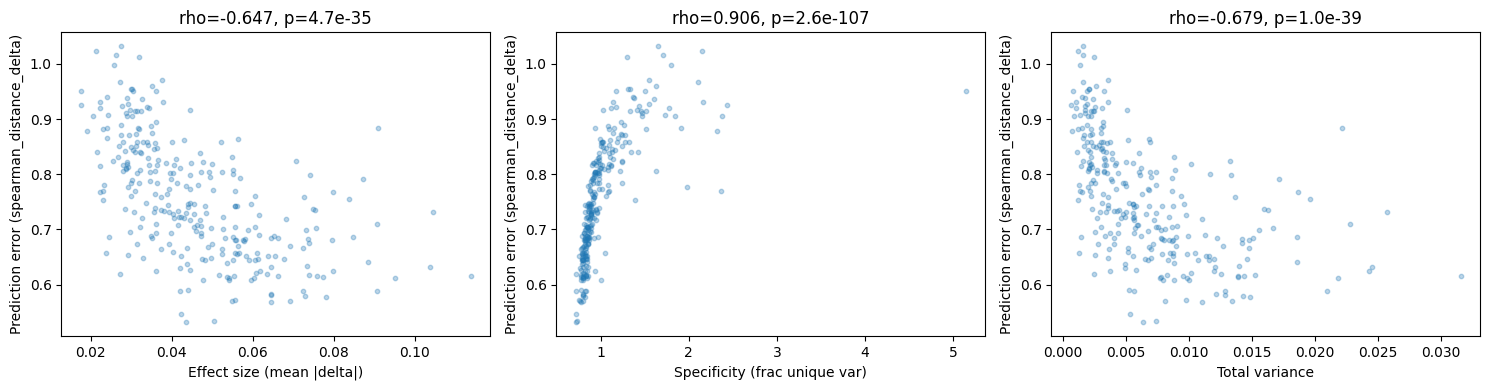

In [17]:
from scipy.stats import spearmanr

results_all = []

for c in gene_perf['dataset'].unique():
    df_temp = gene_perf[(gene_perf['dataset'] == c) & (gene_perf['method'] == 'trainMean')
                        & (gene_perf['deg_rank'] <= 10000)].copy()
    
    # Average across splits
    avg = df_temp.groupby(['perturbation', 'gene']).agg(
        true_delta=('mean_true_delta', 'mean'),
    ).reset_index()
    
    # Gene x perturbation delta matrix
    delta_matrix = avg.pivot(index='gene', columns='perturbation', values='true_delta')
    
    # Gene main effect (alpha_i): average delta across all perturbations
    gene_effect = delta_matrix.mean(axis=1)
    
    records = []
    for pert in delta_matrix.columns:
        col = delta_matrix[pert].dropna()
        gene_eff = gene_effect.loc[col.index]
        
        # Effect size: how strong is this perturbation?
        effect_size = col.abs().mean()
        
        # Residual after removing gene main effect
        residual = col - gene_eff
        
        total_var = col.var()
        resid_var = residual.var()
        
        # Specificity: fraction of variance that is unique to this perturbation
        # High = unique pattern, Low = looks like the average perturbation
        specificity = resid_var / total_var if total_var > 0 else np.nan
        
        records.append({
            'perturbation': pert,
            'dataset': c,
            'effect_size': effect_size,
            'total_var': total_var,
            'specificity': specificity,
            'gene_effect_var': (total_var - resid_var),  # variance explained by alpha_i
        })
    
    results_all.append(pd.DataFrame(records))

pert_features = pd.concat(results_all, ignore_index=True)

# Merge with prediction performance from pivot
pert_features = pert_features.merge(
    pivot.reset_index()[['perturb', 'mean_perf']],
    left_on='perturbation', right_on='perturb', how='inner'
)

# Correlations
print("Spearman correlation with prediction error (mean_perf across cell lines):")
for col in ['effect_size', 'specificity', 'total_var']:
    vals = pert_features.groupby('perturbation')[[col, 'mean_perf']].mean().dropna()
    rho, p = spearmanr(vals[col], vals['mean_perf'])
    print(f"  {col:20s}: rho={rho:.4f}, p={p:.2e}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, 
    ['effect_size', 'specificity', 'total_var'],
    ['Effect size (mean |delta|)', 'Specificity (frac unique var)', 'Total variance']):
    
    vals = pert_features.groupby('perturbation')[[col, 'mean_perf']].mean()
    ax.scatter(vals[col], vals['mean_perf'], alpha=0.3, s=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Prediction error (spearman_distance_delta)')
    rho, p = spearmanr(vals[col], vals['mean_perf'])
    ax.set_title(f'rho={rho:.3f}, p={p:.1e}')

plt.tight_layout()
plt.show()


  Effect size         : rho=-0.6341, p=2.42e-33
  Specificity         : rho=0.9405, p=3.00e-134
  Total variance      : rho=-0.6777, p=1.54e-39


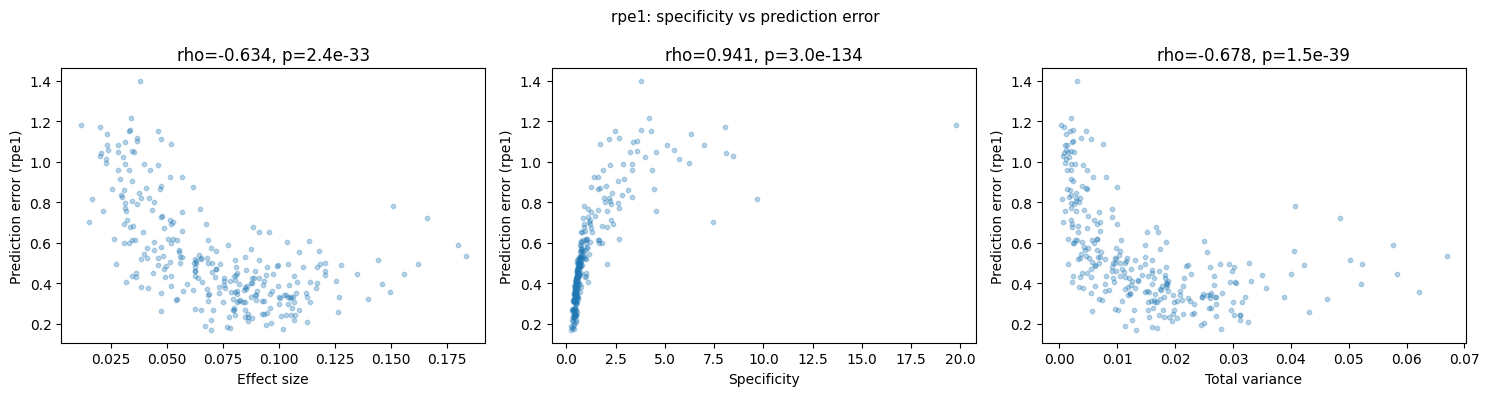

In [18]:
ct = "rpe1"

df_temp = gene_perf[(gene_perf['dataset'] == ct) & (gene_perf['method'] == 'trainMean')
                    & (gene_perf['deg_rank'] <= 10000)].copy()

avg = df_temp.groupby(['perturbation', 'gene']).agg(
    true_delta=('mean_true_delta', 'mean'),
).reset_index()

delta_matrix = avg.pivot(index='gene', columns='perturbation', values='true_delta')
gene_effect = delta_matrix.mean(axis=1)
resid_matrix = delta_matrix.sub(gene_effect, axis=0)

# Per-perturbation specificity
records = []
for pert in delta_matrix.columns:
    col = delta_matrix[pert].dropna()
    residual = col - gene_effect.loc[col.index]
    total_var = col.var()
    resid_var = residual.var()
    records.append({
        'perturbation': pert,
        'specificity': resid_var / total_var if total_var > 0 else np.nan,
        'effect_size': col.abs().mean(),
        'total_var': total_var,
    })
pert_feat = pd.DataFrame(records)

# Merge with cell-type-specific prediction error
perf_col = ct if ct in pivot.columns else "mean_perf"
pert_feat = pert_feat.merge(
    pivot.reset_index()[['perturb', perf_col]].rename(
        columns={'perturb': 'perturbation', perf_col: 'mean_perf'}),
    on='perturbation', how='inner'
)

# Correlations & scatter
from scipy.stats import spearmanr
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
    ['effect_size', 'specificity', 'total_var'],
    ['Effect size', 'Specificity', 'Total variance']):
    rho, p = spearmanr(pert_feat[col], pert_feat['mean_perf'])
    ax.scatter(pert_feat[col], pert_feat['mean_perf'], alpha=0.3, s=10)
    ax.set_xlabel(label)
    ax.set_ylabel(f'Prediction error ({perf_col})')
    ax.set_title(f'rho={rho:.3f}, p={p:.1e}')
    print(f"  {label:20s}: rho={rho:.4f}, p={p:.2e}")
plt.suptitle(f"{ct}: specificity vs prediction error", fontsize=11)
plt.tight_layout()
plt.show()



Using prediction error column: 'K562'
K562: 284 perturbations, 5229 genes, 1485036 gene×pert pairs


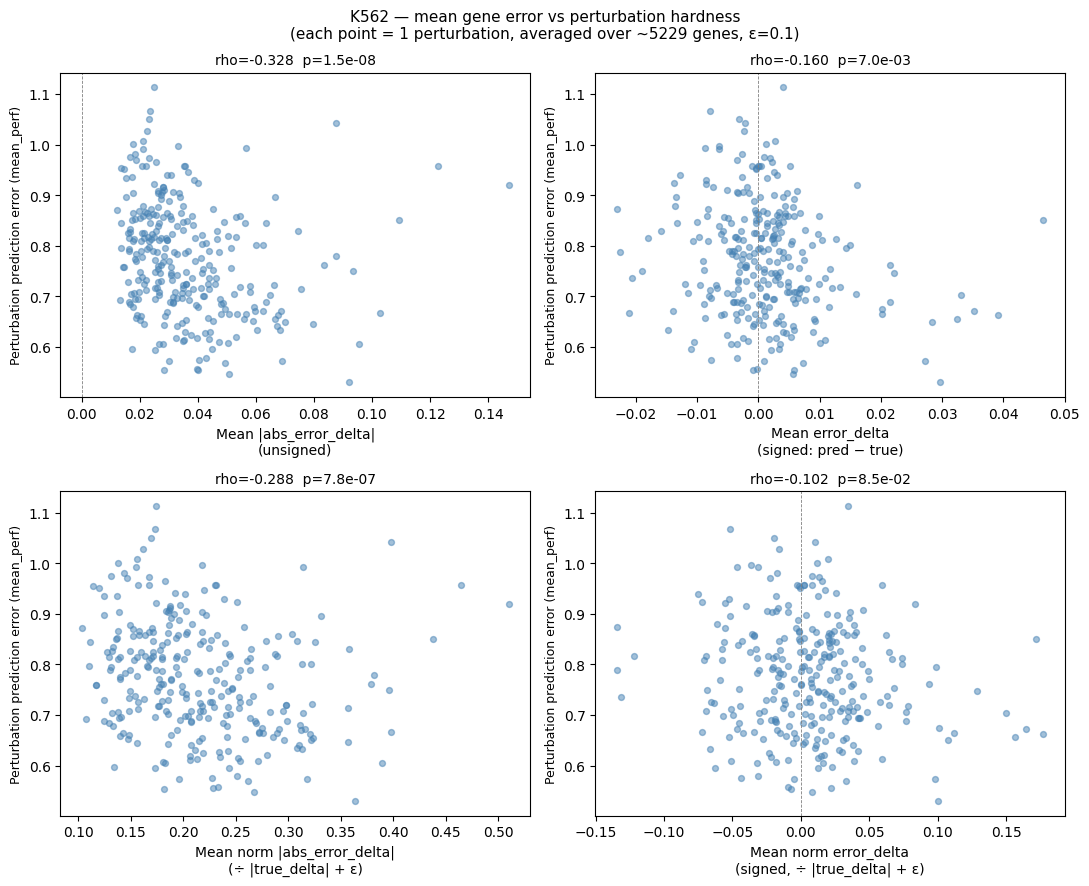


Spearman(mean gene error, pert prediction error):
  Mean |abs_error_delta|                    : rho=-0.3282  p=1.47e-08
  Mean error_delta                          : rho=-0.1598  p=6.97e-03
  Mean norm |abs_error_delta|               : rho=-0.2881  p=7.83e-07
  Mean norm error_delta                     : rho=-0.1025  p=8.47e-02
Thresholds (top/bottom 30%):
  Pert mean_perf  — hard ≥ 0.8302,  easy ≤ 0.7052
  Gene abs_error_delta — hard ≥ 0.0380,  easy ≤ 0.0119

Quadrant counts (total 1,485,036 gene×pert pairs):
  hard_pert/hard_gene      : 122,670  (8.3%)
  hard_pert/easy_gene      : 147,012  (9.9%)
  easy_pert/hard_gene      : 159,254  (10.7%)
  easy_pert/easy_gene      : 119,660  (8.1%)
  middle                   : 936,440  (63.1%)

Top 30 genes by FRACTION of pairs in each quadrant:

  [easy_pert/hard_gene] — idiosyncratic — hard error in easy perts
    HBG2                  : 29% of pairs  (n_total=284)
    HBG1                  : 28% of pairs  (n_total=284)
    HBZ                

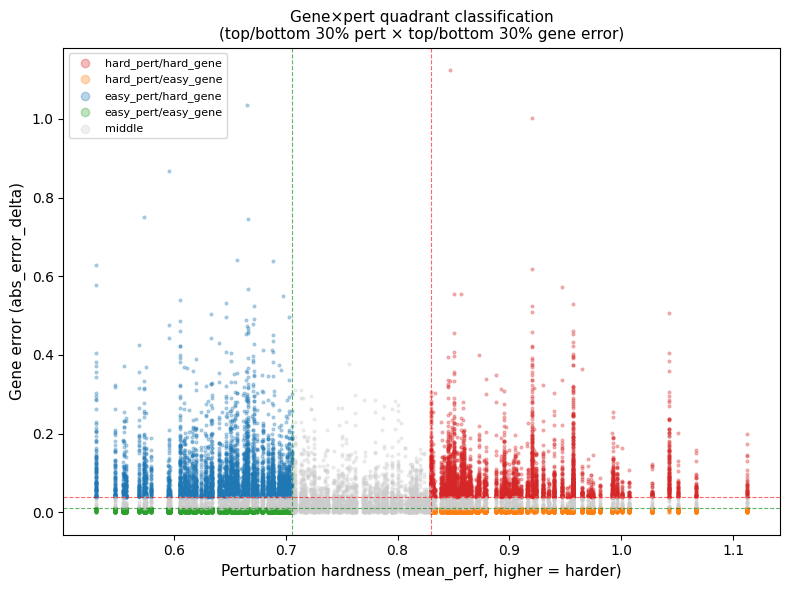

In [75]:
# Cell 10: Per-gene error vs perturbation hardness — 4-metric scatter
from results_modeling_helper import *

ct = "K562"

per_pert_celltype, avg_celltype = plot_gene_error_vs_hardness(
    gene_perf, pivot,
    cell_type=ct,
    method="trainMean",
    deg=10000,
    norm_epsilon=0.1,
)

classified, gene_frac = gene_pert_quadrants(
    avg_celltype, per_pert_celltype,
    pert_top_frac=0.3,
    gene_top_frac=0.3,
    error_col="abs_error_delta",
    top_n=30,
    show_hard_only=False

)



In [71]:
# ── Baseline expression bias check ──────────────────────────────────────
# baseline = control expression = mean_true - mean_true_delta
# Verify: mean_pred - mean_pred_delta should match (same control estimate)

_sub = gene_perf[
    (gene_perf["dataset"] == ct) &
    (gene_perf["method"] == "trainMean") &
    (gene_perf["deg_rank"] <= 10000) &
    (gene_perf["perturbation"].isin(set(pivot.reset_index()["perturb"])))
]

gene_baseline = (
    _sub.assign(
        baseline_true = _sub["mean_true"]  - _sub["mean_true_delta"],
        baseline_pred = _sub["mean_pred"]  - _sub["mean_pred_delta"],
    )
    .groupby("gene")
    .agg(baseline_true=("baseline_true", "mean"),
         baseline_pred=("baseline_pred", "mean"))
)

max_diff = (gene_baseline["baseline_true"] - gene_baseline["baseline_pred"]).abs().max()
print(f"Max |baseline_true - baseline_pred|: {max_diff:.6f}")


Max |baseline_true - baseline_pred|: 0.000001



Spearman(baseline_expr, frac_in_quadrant) — K562:
  easy_pert/hard_gene      : rho=0.891  p=0.00e+00
  hard_pert/hard_gene      : rho=0.923  p=0.00e+00


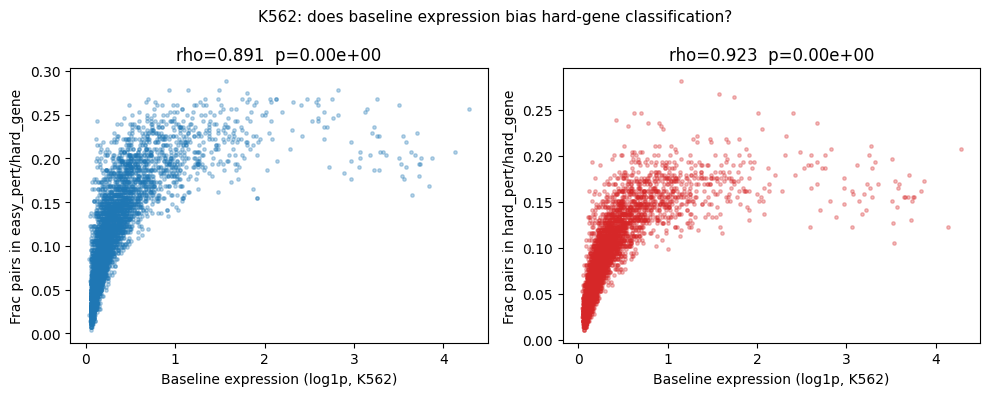

In [76]:
# Merge with gene_frac (from the cell above)
gf = gene_frac.join(gene_baseline, how="left")

# Spearman: does baseline expression predict fraction in hard-gene quadrants?
print(f"\nSpearman(baseline_expr, frac_in_quadrant) — {ct}:")
for q in ["easy_pert/hard_gene", "hard_pert/hard_gene"]:
    if q in gf.columns:
        rho, p = spearmanr(gf["baseline_true"], gf[q], nan_policy="omit")
        print(f"  {q:<25s}: rho={rho:.3f}  p={p:.2e}")

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (q, color) in zip(axes, [
    ("easy_pert/hard_gene", "#1f77b4"),
    ("hard_pert/hard_gene", "#d62728"),
]):
    if q not in gf.columns:
        continue
    ax.scatter(gf["baseline_true"], gf[q], alpha=0.3, s=6, color=color)
    rho, p = spearmanr(gf["baseline_true"], gf[q], nan_policy="omit")
    ax.set_xlabel(f"Baseline expression (log1p, {ct})")
    ax.set_ylabel(f"Frac pairs in {q}")
    ax.set_title(f"rho={rho:.3f}  p={p:.2e}")
plt.suptitle(f"{ct}: does baseline expression bias hard-gene classification?", fontsize=11)
plt.tight_layout()
plt.show()

In [73]:
# classified_rpe1, gene_frac_rpe1 = gene_pert_quadrants(
#     avg_celltype, per_pert_celltype,
#     pert_top_frac=0.1,
#     gene_top_frac=0.1,
#     error_col="norm_abs_error_delta",   # ← switched
#     top_n=30,
#     show_hard_only=True,
# )

# # Re-check bias
# gf2 = gene_frac_rpe1.join(gene_baseline, how="left")
# for q in ["easy_pert/hard_gene", "hard_pert/hard_gene"]:
#     if q in gf2.columns:
#         rho, p = spearmanr(gf2["baseline_true"], gf2[q], nan_policy="omit")
#         print(f"  {q}: rho={rho:.3f}  p={p:.2e}")


Using prediction error column: 'K562'
K562: 284 perturbations, 5229 genes, 1485036 gene×pert pairs


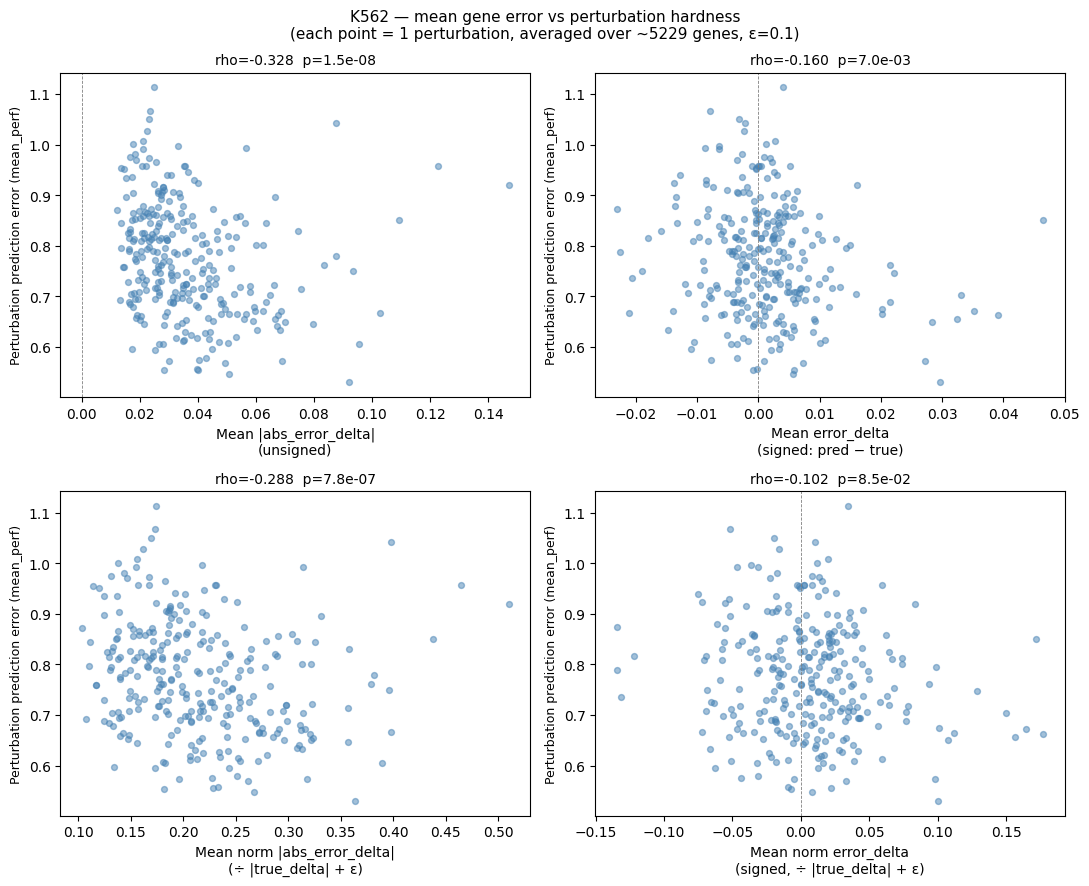


Spearman(mean gene error, pert prediction error):
  Mean |abs_error_delta|                    : rho=-0.3282  p=1.47e-08
  Mean error_delta                          : rho=-0.1598  p=6.97e-03
  Mean norm |abs_error_delta|               : rho=-0.2881  p=7.83e-07
  Mean norm error_delta                     : rho=-0.1025  p=8.47e-02
rho(norm_by_baseline, baseline_expr): -0.146
Thresholds (top/bottom 30%):
  Pert mean_perf  — hard ≥ 0.8302,  easy ≤ 0.7052
  Gene norm_by_baseline — hard ≥ 0.1113,  easy ≤ 0.0362

Quadrant counts (total 1,485,036 gene×pert pairs):
  hard_pert/hard_gene      : 120,745  (8.1%)
  hard_pert/easy_gene      : 149,221  (10.0%)
  easy_pert/hard_gene      : 161,807  (10.9%)
  easy_pert/easy_gene      : 116,434  (7.8%)
  middle                   : 936,829  (63.1%)

Top 30 genes by FRACTION of pairs in each quadrant:

  [easy_pert/hard_gene] — idiosyncratic — hard error in easy perts
    BTG2                  : 27% of pairs  (n_total=284)
    ALAS2                 : 25% 

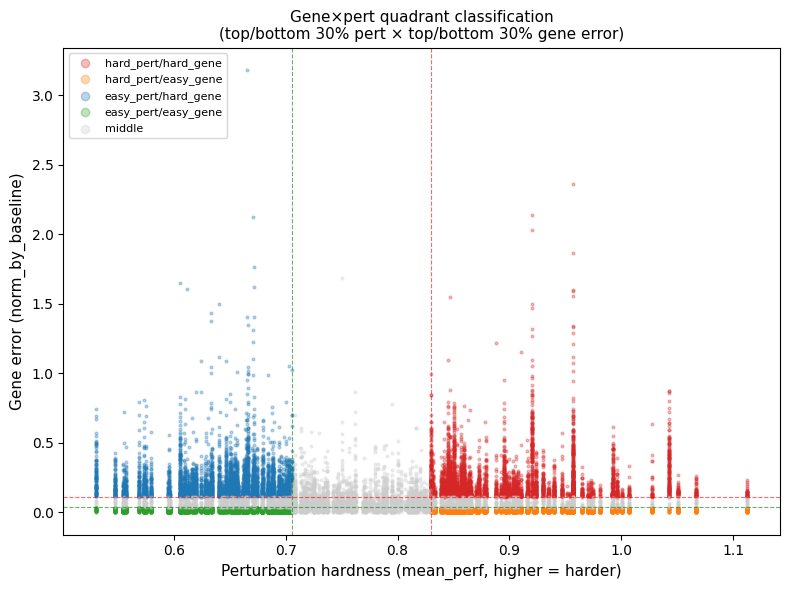

In [77]:
# Cell 10 — same call, norm_by_baseline added automatically
per_pert_celltype, avg_celltype = plot_gene_error_vs_hardness(
    gene_perf, pivot, cell_type=ct, method="trainMean", deg=10000
)

# Check bias with new metric
from scipy.stats import spearmanr
baseline_expr = avg_celltype["mean_true"] - avg_celltype["mean_true_delta"]
rho, _ = spearmanr(avg_celltype["norm_by_baseline"], baseline_expr.abs())
print(f"rho(norm_by_baseline, baseline_expr): {rho:.3f}")

# Cell 11 — use norm_by_baseline
classified, gene_frac = gene_pert_quadrants(
    avg_celltype, per_pert_celltype,
    pert_top_frac=0.3, gene_top_frac=0.3,
    error_col="norm_by_baseline",
    top_n=30, show_hard_only=False,
)
